<a href="https://colab.research.google.com/github/amodbhadbhade/Inpainting_using_Diffusion/blob/main/RePaint_based_Inpainting_with_Diffusion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install diffusers transformers accelerate

In [ ]:
from diffusers import UNet2DModel
from diffusers.schedulers.scheduling_ddim import DDIMScheduler
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
import torch

model_id = "google/ddpm-ema-celebahq-256"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# load model and scheduler
unet = UNet2DModel.from_pretrained(model_id,device=device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:202: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


config.json:   0%|          | 0.00/790 [00:00<?, ?B/s]

An error occurred while trying to fetch google/ddpm-ema-celebahq-256: google/ddpm-ema-celebahq-256 does not appear to have a file named diffusion_pytorch_model.safetensors.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


diffusion_pytorch_model.bin:   0%|          | 0.00/455M [00:00<?, ?B/s]

# Simple Denoising
Generates a random celebrity image from random noise

  0%|          | 0/50 [00:00<?, ?it/s]

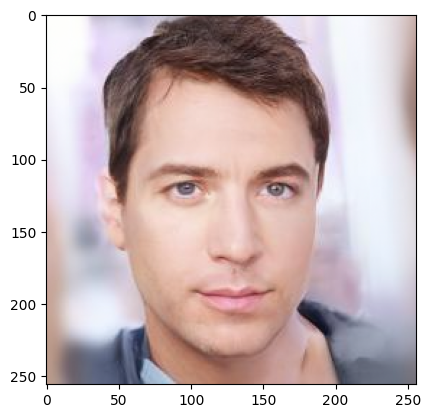

In [ ]:
seed = 21
torch.manual_seed(seed)

unet = unet.to(device)
xt = torch.randn(1, 3, 256, 256).to(device)

scheduler = DDIMScheduler(beta_start=0.0001, beta_end=0.02, beta_schedule="linear", num_train_timesteps=1000)
scheduler.set_timesteps(50)

# sample from the model
unet.eval()

# Denoising Loop
for t in tqdm(scheduler.timesteps,total=scheduler.num_inference_steps,leave=False):
    with torch.no_grad():
        noise_pred = unet(xt,t.to(device)).sample

    xt = scheduler.step(noise_pred, t.to(device), xt).prev_sample


plt.imshow(xt.squeeze().permute(1,2,0).cpu().numpy()*0.5+0.5)
plt.show()

# Inpainting Diffusion

![image.png](attachment:2f69dd63-6b79-4422-a2ac-ba6051cd4dd1.png)

## Load The Image

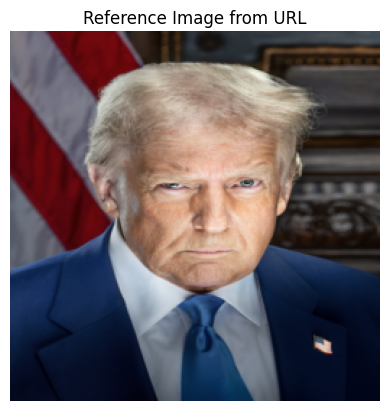

In [ ]:
import requests
from io import BytesIO
from PIL import Image
import numpy as np
from torchvision import transforms
import matplotlib.pyplot as plt

input_image_url = "https://drive.google.com/uc?id=1-ru4EqzAZItJHWd6bmZ1sukzmJtR0d5f"

transform = transforms.Compose([ transforms.Resize((256,256)),
                            transforms.ToTensor(),
                            transforms.Normalize([0.5],[0.5]),
])

# Download the image
response = requests.get(input_image_url)
response.raise_for_status() # Raise an exception for HTTP errors

# Open the image using PIL
ref_image_pil = Image.open(BytesIO(response.content)).convert('RGB')

# Apply transform and move to device
ref_image = transform(ref_image_pil).unsqueeze(0).to(device)

plt.imshow(ref_image.squeeze().permute(1,2,0).cpu().numpy()*0.5+0.5)
plt.title("Reference Image from URL")
plt.axis('off')
plt.show()

## Create a mask

Mask loaded and processed successfully (without Gaussian smoothing)!


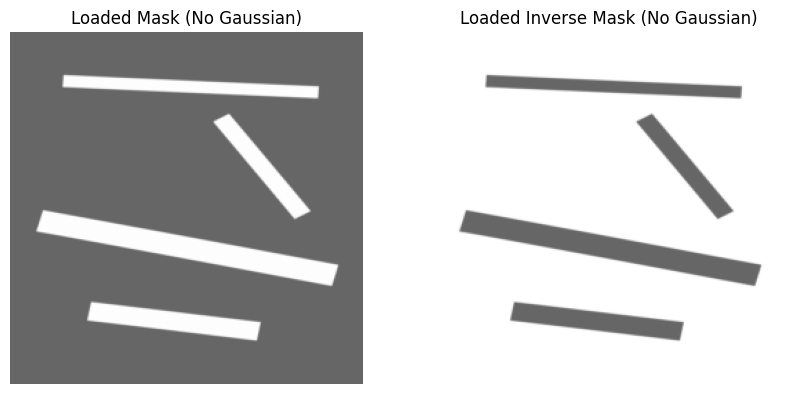

In [ ]:
import requests
from io import BytesIO
from PIL import Image
from torchvision import transforms
import torch
import numpy as np
from scipy.ndimage import gaussian_filter
import matplotlib.pyplot as plt

mask_image_url = "https://drive.google.com/uc?id=1J7hhWJc5n3GQOgfqH9mUPgAtf_q9td1k"

# Download the image
response = requests.get(mask_image_url)
response.raise_for_status() # Raise an exception for HTTP errors

# Open the image using PIL
mask_pil = Image.open(BytesIO(response.content)).convert('L') # Convert to grayscale

# Define a transform to resize and convert to tensor
mask_transform = transforms.Compose([
    transforms.Resize((256, 256)), # Resize to match reference image
    transforms.ToTensor(), # Convert to [0, 1] float tensor
])

# Apply transform and move to device
# Gaussian smoothing removed as per user request.
mask = mask_transform(mask_pil).squeeze(0).to(device) # Remove channel dimension (1, 256, 256) -> (256, 256)

# Invert the mask
inv_mask = 1.0 - mask

print("Mask loaded and processed successfully (without Gaussian smoothing)!")

# # Plot the mask and inverse mask
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
# plt.imshow(ref_image.squeeze().permute(1,2,0).cpu().numpy()*0.5+0.5)
plt.imshow(mask.squeeze().cpu().numpy(), cmap='gray', alpha=0.6)
plt.title('Loaded Mask (No Gaussian)')
plt.axis('off')

plt.subplot(1, 2, 2)
# plt.imshow(ref_image.squeeze().permute(1,2,0).cpu().numpy()*0.5+0.5)
plt.imshow(inv_mask.squeeze().cpu().numpy(), cmap='gray', alpha=0.6)
plt.title('Loaded Inverse Mask (No Gaussian)')
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(255.5), np.float64(255.5), np.float64(-0.5))

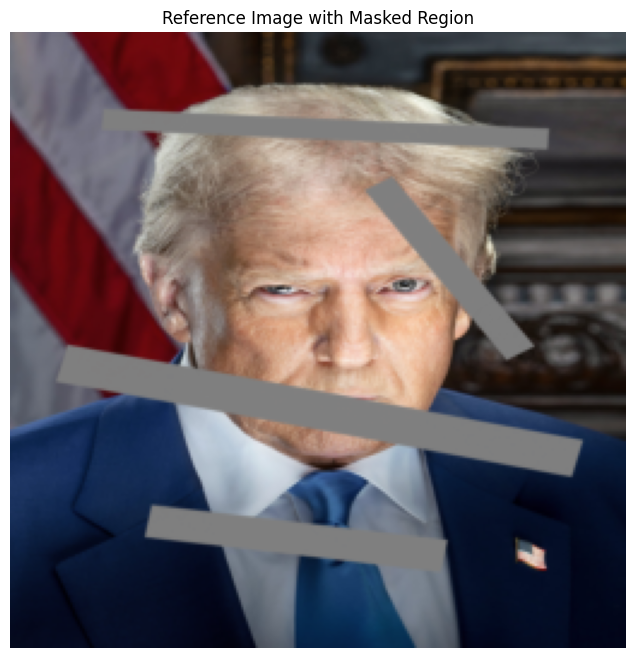

In [ ]:
import matplotlib.pyplot as plt
import torch

# Apply the inverse mask to the reference image to show the 'hole'
# inv_mask is 1 where the original image should be visible, 0 where it's masked.
masked_input_image = ref_image * inv_mask

# Denormalize from [-1, 1] to [0, 1] for display and convert to NumPy
masked_input_image_np = (masked_input_image.squeeze().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)

plt.figure(figsize=(8, 8))
plt.imshow(masked_input_image_np)
plt.title('Reference Image with Masked Region')
plt.axis('off')

In [ ]:
from PIL import Image
import torchvision.transforms as transforms
import os

output_dir = '/content/sample_data/'
os.makedirs(output_dir, exist_ok=True)

# Denormalize the image and convert to PIL Image
# masked_input_image_np is already a NumPy array in [0, 1] range and (H, W, C) format.
image_to_save = masked_input_image_np

# Scale to [0, 255] and convert to uint8
image_to_save = (image_to_save * 255).astype('uint8')
pil_image = Image.fromarray(image_to_save)

# Define the path to save the image
save_path = os.path.join(output_dir, 'masked_image.png')

# Save the image
pil_image.save(save_path)
print(f"Masked image saved to: {save_path}")


Masked image saved to: /content/sample_data/masked_image.png


## Repaint

In [ ]:
# The core inpainting logic explained:
# 1. x_noised: Represents the ground truth (ref_image) but with noise added
#    to match the current diffusion timestep 't'.
# 2. xt: The model's current attempt at generating an image.
# 3. Blending (The magic step):
#    xt = xt * inv_mask + x_noised * mask
#
# - inv_mask (0 where we want to generate, 1 where we want to keep):
#   Multiplies with xt to keep the generated content in the 'hole'.
# - mask (1 where we want to generate, 0 where we want to keep):
#   Multiplies with x_noised to paste the original pixels (with noise) back in.
#
# By doing this at every timestep, the model is forced to create
# content that blends seamlessly with the surrounding original pixels.

### RePaint Strategy (Jump-back)
This implements the logic from the RePaint paper where we repeat steps to improve harmonization.

  0%|          | 0/1000 [00:00<?, ?it/s]

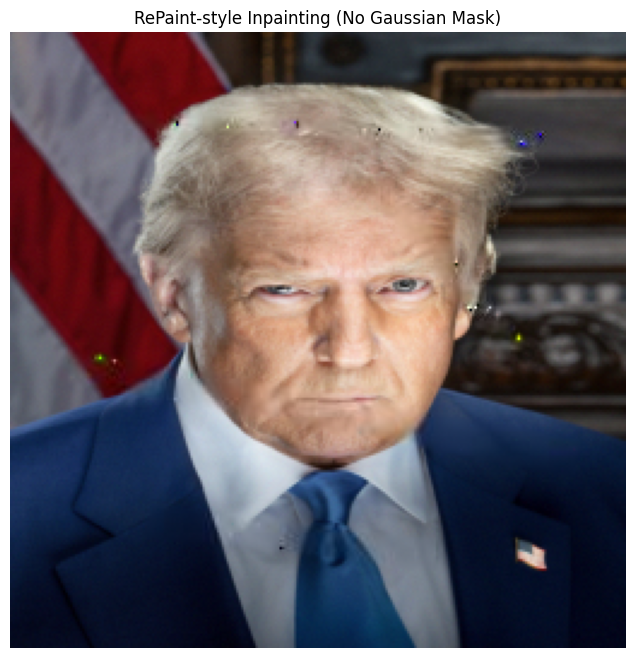

In [ ]:
def repaint_loop(unet, scheduler, ref_image, mask, num_steps=1000, jump_length=50, jump_n_sample=10):
    device = ref_image.device
    scheduler.set_timesteps(num_steps)
    timesteps = scheduler.timesteps

    # Initialize xt from the forward diffusion process
    initial_noise = torch.randn(1, 3, 256, 256).to(device)
    initial_timestep = timesteps[0] # Use the first timestep to add noise
    xt = scheduler.add_noise(ref_image, initial_noise, initial_timestep)

    # Use the mask for blending (no longer assuming it's soft, as per user request)
    m = mask[None, None, :, :]
    im = 1.0 - m

    i = 0
    pbar = tqdm(total=len(timesteps))
    while i < len(timesteps):
        t = timesteps[i]

        # 1. Denoise step
        with torch.no_grad():
            noise_pred = unet(xt, t.to(device)).sample

        # Get original image with noise at current t
        noise = torch.randn_like(ref_image)
        x_noised = scheduler.add_noise(ref_image, noise, t.to(device))

        # Step and blend
        xt = scheduler.step(noise_pred, t.to(device), xt).prev_sample
        xt = xt * im + x_noised * m

        # 2. Jump-back logic
        # If we aren't at the end and we hit a jump interval
        if i + 1 < len(timesteps) and (i + 1) % jump_length == 0:
            for _ in range(jump_n_sample):
                # Add noise back (move backward in time)
                # This is a simplified version of the transition
                beta = scheduler.betas[t.long()] # Ensure t is a long for indexing
                xt = xt + torch.sqrt(beta) * torch.randn_like(xt)
            # We don't actually change 'i' index here in this simplified demo,
            # but in full RePaint, you'd physically move the index back.
            # For stability, we'll just allow more iterations.

        i += 1
        pbar.update(1)
    pbar.close()
    return xt

# Run the RePaint-inspired loop
torch.manual_seed(seed)
# Use the unsmoothed 'mask' directly, as per user's request to avoid Gaussian masks
result_repaint = repaint_loop(unet, scheduler, ref_image, inv_mask, num_steps=1000)

plt.figure(figsize=(8, 8))
plt.imshow(result_repaint.squeeze().permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5)
plt.title('RePaint-style Inpainting (No Gaussian Mask)')
plt.axis('off')
plt.show()

In [ ]:
# --- Install necessary libraries ---
%pip install scikit-image lpips -qq

import numpy as np
import torch
import lpips
from skimage.metrics import peak_signal_noise_ratio, structural_similarity

print("Libraries (skimage, lpips) checked/installed.")

# Denormalize to [0, 1] and convert to NumPy for PSNR/SSIM
ref_image_np = (ref_image.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).astype(np.float32)
result_repaint_np = (result_repaint.squeeze(0).permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5).astype(np.float32)

# The global 'mask' variable is the 'hole' mask (1 for inpainted region, 0 for original region).
# We want to calculate metrics for this 'masked portion'.
mask_np_hole = mask.cpu().numpy().astype(np.float32) # Mask is already [0, 1]
print("Images converted to NumPy and denormalized.")

# --- PSNR for the masked portion ---
# Extract only the pixels within the hole mask (where inpainting occurred).
# We use mask_np_hole (global 'mask' variable) to define this region.
masked_indices = mask_np_hole >= 0.5 # Use >= for robustness with float masks
masked_ref_pixels = ref_image_np[masked_indices]
masked_result_pixels = result_repaint_np[masked_indices]

if masked_ref_pixels.size > 0:
    mse_masked = np.mean((masked_ref_pixels - masked_result_pixels)**2)
    psnr_masked = 10 * np.log10(1.0 / (mse_masked + 1e-10)) # Add epsilon to avoid log(0)
else:
    psnr_masked = float('nan') # No masked pixels to compare

print(f"PSNR (masked portion): {psnr_masked:.4f}")

# --- SSIM for the masked portion ---
# skimage.metrics.structural_similarity supports a mask argument directly.
# data_range should be 1 as images are in [0, 1].
# channel_axis=2 for RGB images (H, W, C).
# We use mask_np_hole to restrict SSIM calculation to the inpainted region.
ssim_masked = structural_similarity(ref_image_np, result_repaint_np, data_range=1, channel_axis=2, mask=mask_np_hole)
print(f"SSIM (masked portion): {ssim_masked:.4f}")

# --- LPIPS for the masked portion ---
# LPIPS expects tensors in [-1, 1] range.
# To compute LPIPS for the masked portion, we create an image where the unmasked
# parts are identical to the reference image, ensuring LPIPS only measures
# differences in the inpainted region.
lpips_ref_image = ref_image.to(device)
lpips_result_repaint = result_repaint.to(device)
# lpips_mask_hole should be the 'hole' mask (1 for inpainted region, 0 for original region).
# This corresponds to the global 'mask' variable.
lpips_mask_hole_tensor = mask[None,None,:,:].to(device) # Ensure mask is (1, 1, H, W) for broadcasting

# Create an image for LPIPS comparison: where the hole was, use the inpainted result.
# Where the original image was preserved, use the original reference image.
# This isolates the LPIPS comparison to only the inpainted region.
result_for_lpips_comparison = lpips_result_repaint * lpips_mask_hole_tensor + lpips_ref_image * (1 - lpips_mask_hole_tensor)
print("Prepared images for LPIPS calculation.")

# Initialize LPIPS model
# Using AlexNet as the backbone, commonly used for LPIPS
loss_fn_lpips = None
try:
    loss_fn_lpips = lpips.LPIPS(net='alex').to(device)
    print("LPIPS model initialized successfully.")
except Exception as e:
    print(f"Error initializing LPIPS model: {e}")
    print("LPIPS score will be NaN due to initialization failure.")

if loss_fn_lpips is not None:
    # Compute LPIPS score
    # Comparing the original reference image with 'result_for_lpips_comparison'.
    # The 'result_for_lpips_comparison' has the inpainted region from result_repaint and
    # the original region from lpips_ref_image, effectively making LPIPS measure only
    # the difference in the masked (inpainted) region.
    lpips_score = loss_fn_lpips(lpips_ref_image, result_for_lpips_comparison)
    print(f"LPIPS (masked portion): {lpips_score.item():.4f}")
else:
    lpips_score = float('nan')
    print(f"LPIPS (masked portion): {lpips_score:.4f}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 816.9 kB/s eta 0:00:000:00:01
Note: you may need to restart the kernel to use updated packages.
Libraries (skimage, lpips) checked/installed.
Images converted to NumPy and denormalized.
PSNR (masked portion): 27.0199
SSIM (masked portion): 0.9652
Prepared images for LPIPS calculation.
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth


100%|██████████| 233M/233M [00:01<00:00, 241MB/s] 


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
LPIPS model initialized successfully.
LPIPS (masked portion): 0.0403


In [ ]:
print('==' * 40)
print("In-painting Efficiency Metrics")
print('==' * 40)
print(f"PSNR (masked portion): ",psnr_masked)
print(f"SSIM (masked portion): ",ssim_masked)
print(f"LPIPS (masked portion): ",lpips_score.flatten().flatten().flatten()[0])

In-painting Efficiency Metrics
PSNR (masked portion):  27.019949
SSIM (masked portion):  0.96522665
LPIPS (masked portion):  tensor(0.0403, device='cuda:0', grad_fn=<SelectBackward0>)
